# Day 4 - Fund Performance Analytics

In [7]:
import pandas as pd
import numpy as np
from IPython.display import Image

nav = pd.read_csv("data/processed/02_nav_history.csv")
funds = pd.read_csv("data/processed/01_fund_master.csv")
bench = pd.read_csv("data/processed/10_benchmark_indices.csv")
score = pd.read_csv("reports/fund_scorecard.csv")
alpha_beta = pd.read_csv("reports/alpha_beta.csv")

nav["date"] = pd.to_datetime(nav["date"])
bench["date"] = pd.to_datetime(bench["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Daily Returns

In [8]:
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


## CAGR Analysis

In [9]:
alpha_beta[["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]] \
    .sort_values("cagr_3yr_pct", ascending=False) \
    .head(10)

,scheme_name,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
16,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.535034
34,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.314980
24,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,20.511682
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.412844
25,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.893882
19,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.402073
30,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.287126
36,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.417077
3,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.414973
39,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,28.187713


## Sharpe Ratio Ranking

In [10]:
alpha_beta[["scheme_name", "sharpe_ratio"]] \
    .sort_values("sharpe_ratio", ascending=False) \
    .head(10)

,scheme_name,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,Kotak Flexicap Fund - Regular - Growth,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,DSP Midcap Fund - Regular - Growth,1.132122
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
9,Nippon India Large Cap Fund - Regular - Growth,1.081659
3,ABSL Frontline Equity Fund - Regular - Growth,1.027213
24,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


## Sortino Ratio Ranking

In [11]:
alpha_beta[["scheme_name", "sortino_ratio"]] \
    .sort_values("sortino_ratio", ascending=False) \
    .head(10)

,scheme_name,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
30,Kotak Flexicap Fund - Regular - Growth,2.364320
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
19,SBI Bluechip Fund - Regular Plan - Growth,2.140267
25,ICICI Pru Midcap Fund - Regular - Growth,2.029353
38,DSP Midcap Fund - Regular - Growth,1.875101
9,Nippon India Large Cap Fund - Regular - Growth,1.850133
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
24,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
3,ABSL Frontline Equity Fund - Regular - Growth,1.799563


## Alpha and Beta Analysis

In [12]:
alpha_beta[["scheme_name", "alpha_pct", "beta"]] \
    .sort_values("alpha_pct", ascending=False) \
    .head(10)

,scheme_name,alpha_pct,beta
21,SBI Small Cap Fund - Regular Plan - Growth,30.336965,-0.023196
39,DSP Small Cap Fund - Regular - Growth,30.057878,0.011455
25,ICICI Pru Midcap Fund - Regular - Growth,29.263583,0.000549
36,Mirae Asset Tax Saver Fund - Regular - Growth,28.270368,0.018134
30,Kotak Flexicap Fund - Regular - Growth,27.330465,-0.022830
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.195355,0.005104
34,Mirae Asset Large Cap Fund - Regular - Growth,26.983751,0.023684
38,DSP Midcap Fund - Regular - Growth,26.598578,-0.002523
16,Axis Midcap Fund - Regular - Growth,26.076669,-0.066265
19,SBI Bluechip Fund - Regular Plan - Growth,23.201007,-0.031751


## Maximum Drawdown

In [13]:
alpha_beta[["scheme_name", "max_drawdown_pct", "max_drawdown_date"]] \
    .sort_values("max_drawdown_pct") \
    .head(10)

,scheme_name,max_drawdown_pct,max_drawdown_date
22,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,2025-10-28
17,Axis Small Cap Fund - Regular - Growth,-51.677754,2026-05-11
4,ABSL Small Cap Fund - Regular - Growth,-35.446916,2026-05-11
39,DSP Small Cap Fund - Regular - Growth,-31.171900,2025-01-03
21,SBI Small Cap Fund - Regular Plan - Growth,-28.706006,2025-05-14
7,UTI Mid Cap Fund - Regular - Growth,-28.001124,2026-04-27
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,2022-09-15
29,Kotak Emerging Equity Fund - Regular - Growth,-24.003511,2024-10-17
11,Nippon India Small Cap Fund - Regular - Growth,-23.344886,2026-02-20
15,Axis Bluechip Fund - Direct - Growth,-21.751396,2023-05-22


## Fund Scorecard

In [15]:
score[[
    "scheme_name",
    "final_score",
    "cagr_3yr_pct",
    "sharpe_ratio",
    "alpha_pct",
    "expense_ratio_pct",
    "max_drawdown_pct"
]].head(10)

,scheme_name,final_score,cagr_3yr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,max_drawdown_pct
0,Mirae Asset Large Cap Fund - Regular - Growth,86.2500,34.000916,1.448291,26.983751,1.46,-11.265729
1,ICICI Pru Midcap Fund - Regular - Growth,82.2500,31.777537,1.180101,29.263583,1.36,-18.188514
2,Kotak Flexicap Fund - Regular - Growth,82.0000,29.582770,1.306744,27.330465,1.45,-12.973968
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500,32.442459,1.093699,27.195355,1.38,-16.217209
4,ICICI Pru Bluechip Fund - Direct - Growth,80.0000,32.487429,1.026524,21.194827,0.80,-12.588276
5,Axis Midcap Fund - Regular - Growth,77.0000,35.111802,0.998231,26.076669,1.38,-20.960884
6,SBI Bluechip Fund - Regular Plan - Growth,74.8125,30.456524,1.208267,23.201007,1.54,-15.012385
7,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875,29.178902,1.234930,28.270368,1.60,-16.396743
8,ABSL Frontline Equity Fund - Regular - Growth,68.1875,28.967695,1.027213,21.399785,1.60,-11.291596
9,SBI Small Cap Fund - Regular Plan - Growth,67.3750,26.669922,0.945308,30.336965,1.43,-28.706006


## Benchmark Comparison Chart

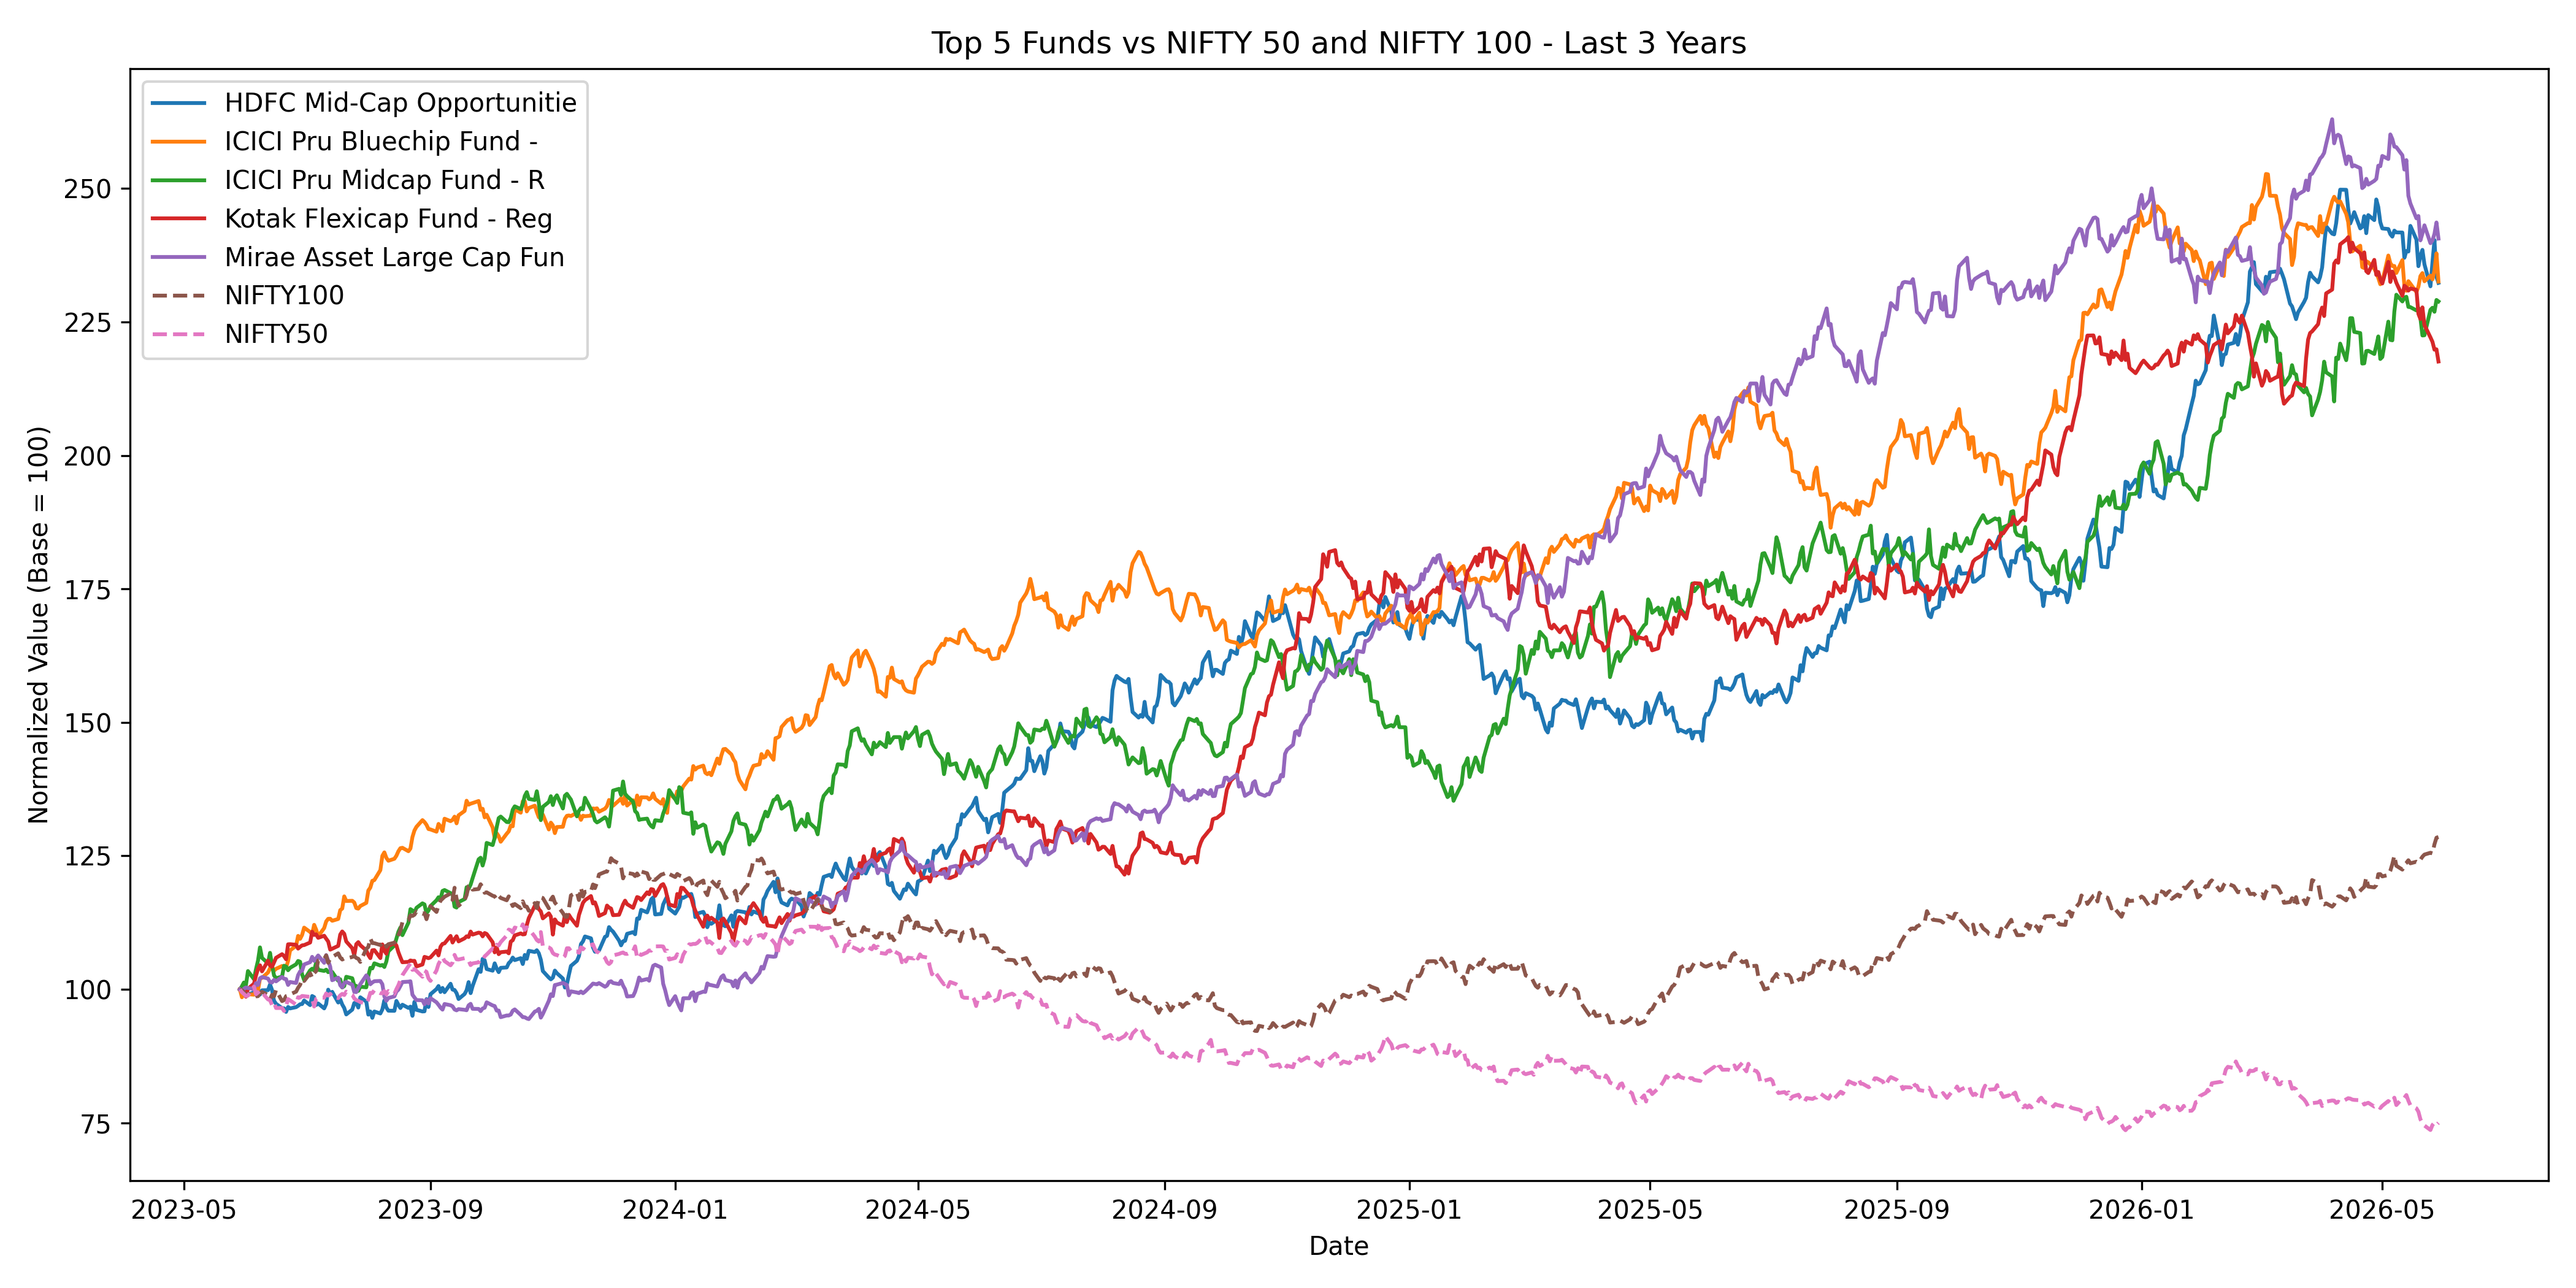

In [16]:
Image("reports/charts/benchmark_comparison.png")

## Key Findings

1. Daily returns were computed for all 40 mutual fund schemes.
2. CAGR values were generated for 1-year, 3-year, and 5-year periods.
3. Sharpe Ratio was used to rank funds based on risk-adjusted returns.
4. Sortino Ratio helped evaluate downside-risk-adjusted performance.
5. Alpha and Beta were calculated against the NIFTY100 benchmark.
6. Maximum Drawdown identified the worst NAV fall for each fund.
7. The fund scorecard combines return, Sharpe, alpha, expense ratio, and drawdown.
8. Lower expense ratio improves the final score because cost affects investor returns.
9. Benchmark comparison shows top funds against NIFTY50 and NIFTY100.
10. The final scorecard can support fund selection and dashboard ranking.

In [5]:
import os
print(os.getcwd())

C:\Users\Sanjay Kumar\bluestock_mf_capstone


In [6]:
import os
print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', '04_performance_analytics.ipynb', 'dashboard', 'data', 'db', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'scripts', 'sql', 'venv']
